# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [97]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import make_scorer, f1_score


try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [98]:
ZIP_PATH = 'Heart Disease Prediction Dataset.zip'  # or your path
EXTRACT_DIR = 'heart_ds'
FILE_NAME = "dataset_heart.csv"
# zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)

In [99]:

# TODO: load the CSV into a DataFrame named df
df = pd.read_csv(FILE_NAME)

# TODO: inspect df
print(df.columns)
df = df.rename(columns={'sex ': 'sex'})
print(df.columns)

print(df.shape)
display(df.head())
print(df.dtypes)
display(df.isna().sum().sort_values(ascending=False))

# TODO: identify target column
target = 'heart disease'
df[target] = df[target].map({1: 0, 2: 1})


# TODO: split features and target
X = df.drop(columns=[target])
y = df[target]

# TODO: train test split with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


Index(['age', 'sex ', 'chest pain type', 'resting blood pressure',
       'serum cholestoral', 'fasting blood sugar',
       'resting electrocardiographic results', 'max heart rate',
       'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels',
       'thal', 'heart disease'],
      dtype='str')
Index(['age', 'sex', 'chest pain type', 'resting blood pressure',
       'serum cholestoral', 'fasting blood sugar',
       'resting electrocardiographic results', 'max heart rate',
       'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels',
       'thal', 'heart disease'],
      dtype='str')
(270, 14)


,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1


age                                       int64
sex                                       int64
chest pain type                           int64
resting blood pressure                    int64
serum cholestoral                         int64
fasting blood sugar                       int64
resting electrocardiographic results      int64
max heart rate                            int64
exercise induced angina                   int64
oldpeak                                 float64
ST segment                                int64
major vessels                             int64
thal                                      int64
heart disease                             int64
dtype: object


age                                     0
sex                                     0
chest pain type                         0
resting blood pressure                  0
serum cholestoral                       0
fasting blood sugar                     0
resting electrocardiographic results    0
max heart rate                          0
exercise induced angina                 0
oldpeak                                 0
ST segment                              0
major vessels                           0
thal                                    0
heart disease                           0
dtype: int64

### Basic visual checks

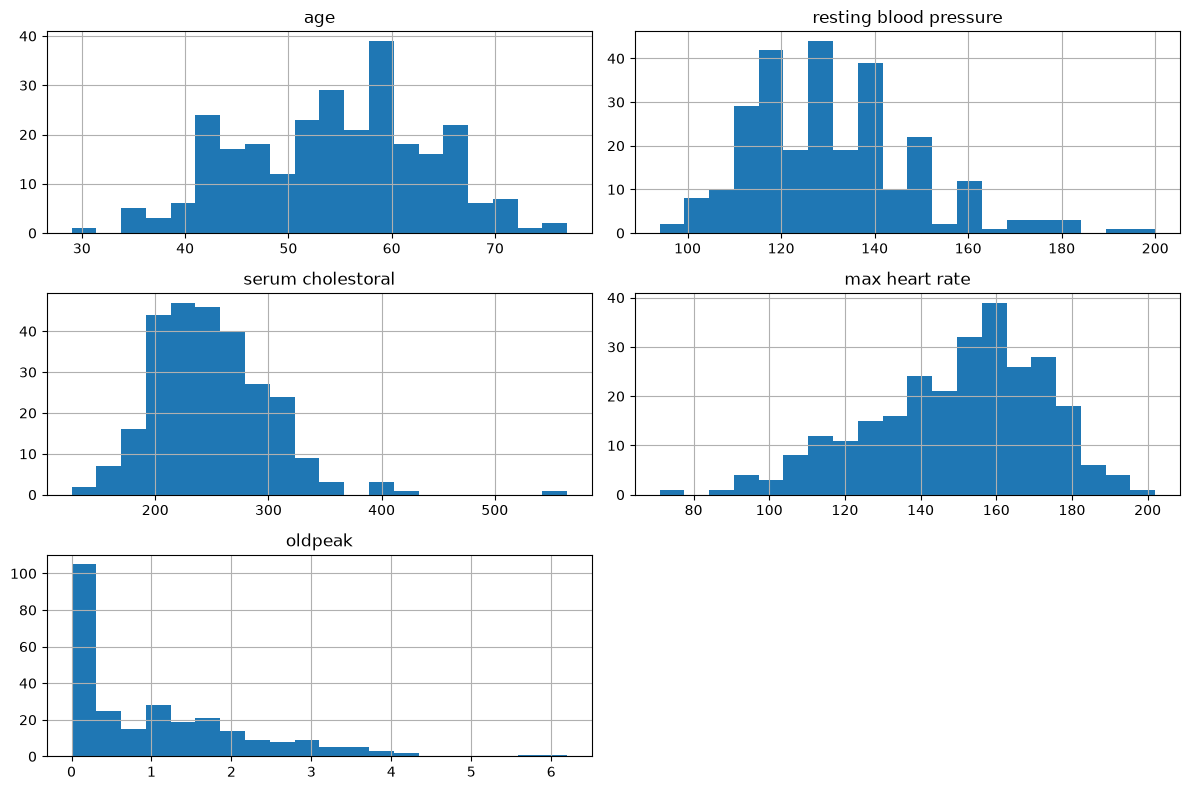

In [100]:

# TODO: pick a few numeric columns and plot histograms
num_cols_to_plot = ['age', 'resting blood pressure', 'serum cholestoral', 'max heart rate', 'oldpeak']
df[num_cols_to_plot].hist(bins=20, figsize=(12, 8))
plt.tight_layout()
plt.show()

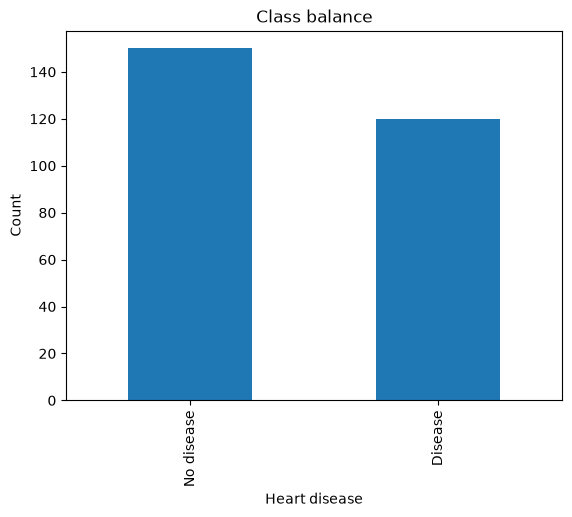

In [101]:

# TODO: plot class balance as a bar chart
labels_map = {0: 'No disease', 1: 'Disease'}
df['heart disease'].map(labels_map).value_counts().plot(kind='bar')
plt.xlabel('Heart disease')
plt.ylabel('Count')
plt.title('Class balance')
plt.show()

## Preprocessing pipeline

In [102]:
print(target)
print(df.columns)
cat_cols = ['sex', 'chest pain type', 'fasting blood sugar',
            'resting electrocardiographic results', 'exercise induced angina',
            'ST segment', 'major vessels', 'thal']
num_cols = ['age', 'resting blood pressure', 'serum cholestoral',
            'max heart rate', 'oldpeak']

pre = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

heart disease
Index(['age', 'sex', 'chest pain type', 'resting blood pressure',
       'serum cholestoral', 'fasting blood sugar',
       'resting electrocardiographic results', 'max heart rate',
       'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels',
       'thal', 'heart disease'],
      dtype='str')


## Helper - evaluation function

In [103]:
def eval_and_report(name, model, X_test, y_test, color):
    """Compute metrics and draw confusion matrix and ROC if available.
    Fill in the missing parts.
    """
    # TODO: predictions
    y_pred = model.predict(X_test)

    # TODO: compute metrics dict with accuracy, precision, recall, f1
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
    }
    print(name, metrics)

    # TODO: confusion matrix plot
    # confusion_matrix(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=color)
    plt.title(f'{name} - Confusion Matrix')
    plt.show()

    # TODO: ROC curve if model has predict_proba
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        # fpr, tpr, _ = roc_curve(y_test, y_proba, pos_label=y_test.max())
        fpr, tpr, _ = roc_curve(y_test, y_proba)

        auc = roc_auc_score(y_test, y_proba)

        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{name} - ROC Curve')
        plt.legend()
        plt.show()

    metrics['roc_auc'] = auc

    return metrics


## Exercise 2 - Logistic Regression without Grid Search

LR no grid {'accuracy': 0.8703703703703703, 'precision': 0.8148148148148148, 'recall': 0.9166666666666666, 'f1': 0.8627450980392157}


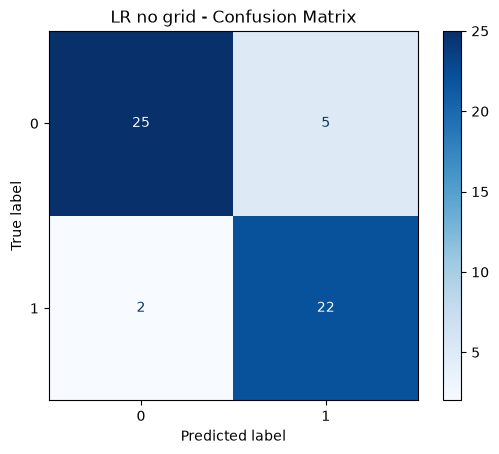

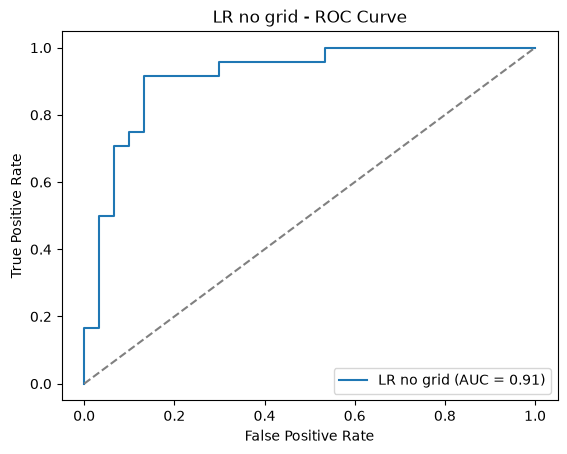

In [104]:

# TODO: create a Pipeline with your preprocessor and LogisticRegression
# Hint: solver 'liblinear' is fine, increase max_iter if needed
# pipe_lr = None
pipe_lr = Pipeline(steps=[
    ('pre', pre),
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

# TODO: fit on training data
pipe_lr.fit(X_train, y_train)

# TODO: evaluate with eval_and_report
lr_no_gs_metrics = eval_and_report('LR no grid', pipe_lr, X_test, y_test, 'Blues')


## Exercise 3 - Logistic Regression with Grid Search

Best params: {'lr__C': 0.1, 'lr__penalty': 'l2'}
LR grid {'accuracy': 0.8703703703703703, 'precision': 0.8148148148148148, 'recall': 0.9166666666666666, 'f1': 0.8627450980392157}


c:\Users\avigd\Desktop\GENAI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


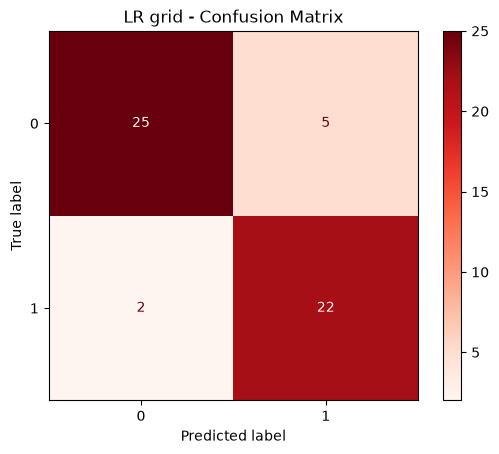

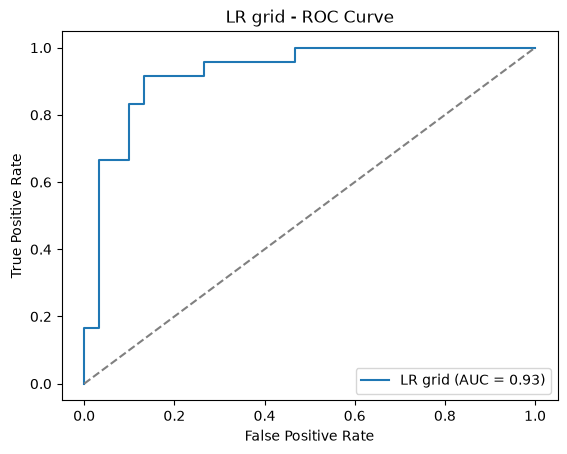

In [105]:

# TODO: build a Pipeline same as above
pipe_lr_cv = Pipeline(steps=[
    ('pre', pre),
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

# TODO: define param_grid for lr__C and lr__penalty
# Hint: use small to large C values. 'liblinear' supports 'l1' and 'l2'.
param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2'],
}

# TODO: GridSearchCV with cv=5 and scoring='f1'
grid_lr = GridSearchCV(pipe_lr_cv, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)
print('Best params:', grid_lr.best_params_)
best_lr = grid_lr.best_estimator_
lr_gs_metrics = eval_and_report('LR grid', best_lr, X_test, y_test, 'Reds')



## Exercise 4 - SVM without Grid Search

SVM no grid {'accuracy': 0.8518518518518519, 'precision': 0.7857142857142857, 'recall': 0.9166666666666666, 'f1': 0.8461538461538461}


c:\Users\avigd\Desktop\GENAI\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


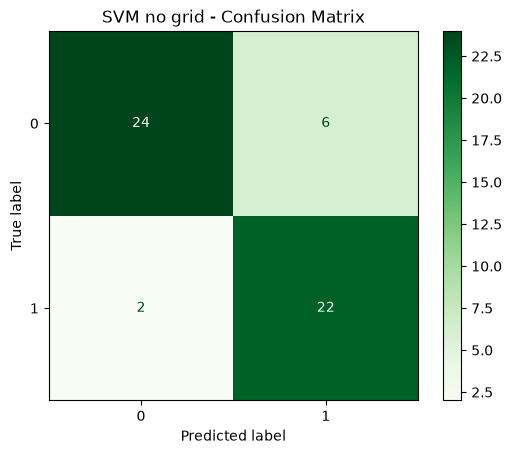

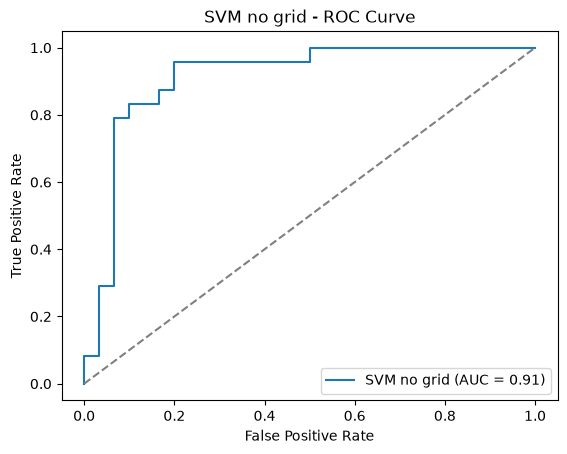

In [106]:
pipe_svm = Pipeline(steps=[
    ('pre', pre),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE))
])
pipe_svm.fit(X_train, y_train)
svm_no_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test, 'Greens')


## Exercise 5 - SVM with Grid Search

Best params: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
SVM grid {'accuracy': 0.8518518518518519, 'precision': 0.8076923076923077, 'recall': 0.875, 'f1': 0.84}


c:\Users\avigd\Desktop\GENAI\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


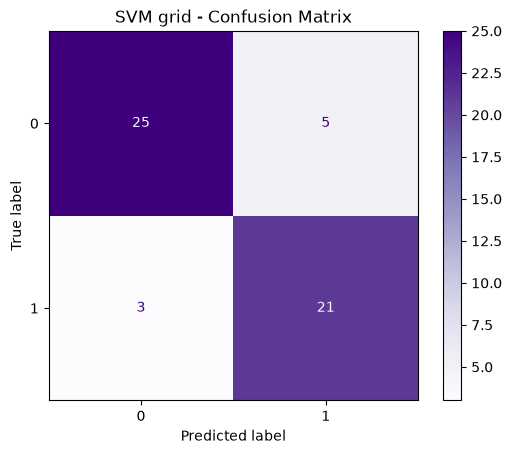

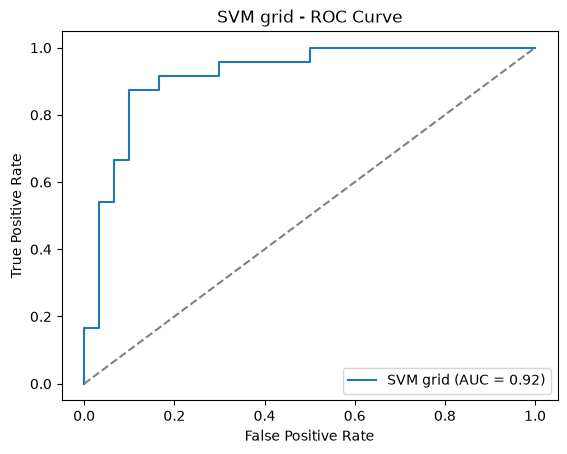

In [107]:
pipe_svm_cv = Pipeline(steps=[
    ('pre', pre),
    ('svm', SVC(probability=True, random_state=RANDOM_STATE))
])

svm_param_grid = {
    'svm__kernel': ['rbf', 'linear'],
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto'],
}

grid_svm = GridSearchCV(pipe_svm_cv, svm_param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_svm.fit(X_train, y_train)

print('Best params:', grid_svm.best_params_)
best_svm = grid_svm.best_estimator_
svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test, 'Purples')

## Exercise 6 - XGBoost without Grid Search

XGB no grid {'accuracy': 0.8333333333333334, 'precision': 0.8, 'recall': 0.8333333333333334, 'f1': 0.8163265306122449}


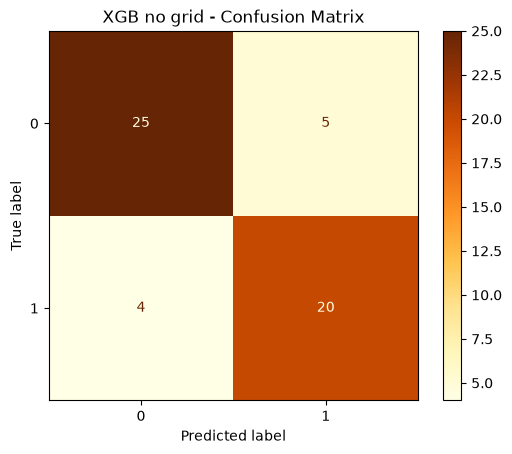

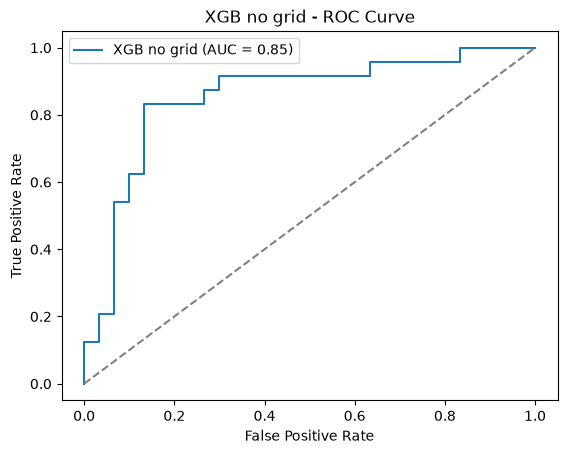

In [109]:
pipe_xgb = Pipeline(steps=[
    ('pre', pre),
    ('xgb', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=4,
        random_state=RANDOM_STATE,
        eval_metric='logloss'
    ))
])

pipe_xgb.fit(X_train, y_train)

xgb_no_metrics = eval_and_report('XGB no grid', pipe_xgb, X_test, y_test, 'YlOrBr')


## Exercise 7 - XGBoost with Grid Search

Best params: {'xgb__colsample_bytree': 1.0, 'xgb__learning_rate': 0.2, 'xgb__max_depth': 3, 'xgb__n_estimators': 300, 'xgb__subsample': 0.8}
XGB grid {'accuracy': 0.7962962962962963, 'precision': 0.7407407407407407, 'recall': 0.8333333333333334, 'f1': 0.7843137254901961}


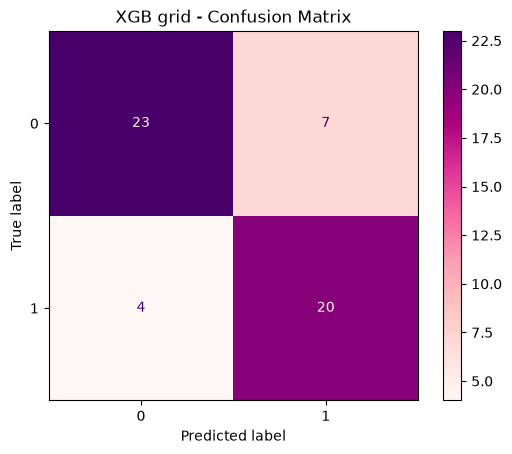

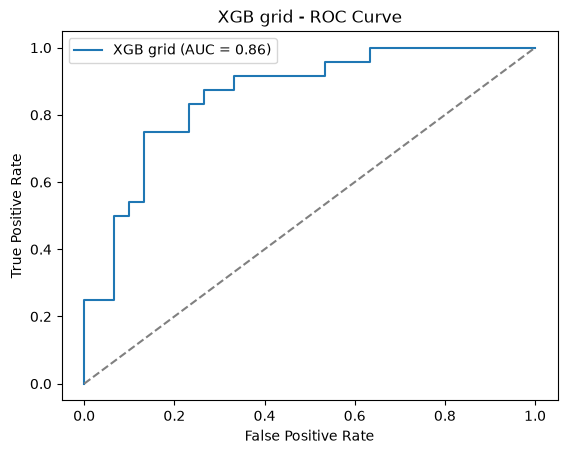

In [111]:
pipe_xgb_cv = Pipeline(steps=[
    ('pre', pre),
    ('xgb', XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))
])

xgb_param_grid = {
    'xgb__n_estimators': [100, 300, 500],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__max_depth': [3, 4, 5],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0],
}

grid_xgb = GridSearchCV(pipe_xgb_cv, xgb_param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

print('Best params:', grid_xgb.best_params_)
best_xgb = grid_xgb.best_estimator_
xgb_gs_metrics = eval_and_report('XGB grid', best_xgb, X_test, y_test, 'RdPu')

## Compare models

In [112]:
summary = {
    'LR no grid': lr_no_gs_metrics,
    'LR grid': lr_gs_metrics,
    'SVM no grid': svm_no_metrics,
    'SVM grid': svm_gs_metrics,
    'XGB no grid': xgb_no_metrics,
    'XGB grid': xgb_gs_metrics,
}

summary_df = pd.DataFrame.from_dict(summary, orient='index')
summary_df

,accuracy,precision,recall,f1,roc_auc
LR no grid,0.870370,0.814815,0.916667,0.862745,0.913889
LR grid,0.870370,0.814815,0.916667,0.862745,0.925000
SVM no grid,0.851852,0.785714,0.916667,0.846154,0.911111
SVM grid,0.851852,0.807692,0.875000,0.840000,0.918056
XGB no grid,0.833333,0.800000,0.833333,0.816327,0.854167
XGB grid,0.796296,0.740741,0.833333,0.784314,0.858333
